In [1]:

import seaborn as sns
import pandas as pd


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Clean academic style
plt.style.use('seaborn-v0_8-whitegrid')

# Custom color palette
COLORS = {
    'primary': '#2C7BB6',    # nice blue
    'secondary': '#D7191C',  # red for comparisons
    'accent': '#1A9641',     # green
    'neutral': '#636363',    # grey
    'highlight': '#FDAE61',  # orange
}

# Better defaults
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10

In [3]:
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\processed_data\enriched_data.csv", index_col='timestamp', parse_dates=['timestamp'])

In [4]:
df.head()

,load,hour,day_of_week,month,year
timestamp,,,,,
2023-01-01 00:00:00,5317.916667,0,6,1,2023
2023-01-01 01:00:00,5271.333333,1,6,1,2023
2023-01-01 02:00:00,5142.833333,2,6,1,2023
2023-01-01 03:00:00,5110.250000,3,6,1,2023
2023-01-01 04:00:00,5126.833333,4,6,1,2023


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2023-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   load         26304 non-null  float64
 1   hour         26304 non-null  int64  
 2   day_of_week  26304 non-null  int64  
 3   month        26304 non-null  int64  
 4   year         26304 non-null  int64  
dtypes: float64(1), int64(4)
memory usage: 1.2 MB


In [6]:
df.describe()

,load,hour,day_of_week,month,year
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.00000
mean,8227.460172,11.500000,2.997263,6.521898,2024.00000
std,2817.568235,6.922318,2.001632,3.449052,0.81614
min,3084.000000,0.000000,0.000000,1.000000,2023.00000
25%,6156.687500,5.750000,1.000000,4.000000,2023.00000
50%,7664.875000,11.500000,3.000000,7.000000,2024.00000
75%,9451.937500,17.250000,5.000000,10.000000,2025.00000
max,18566.658854,23.000000,6.000000,12.000000,2025.00000


In [7]:
df.corr()

,load,hour,day_of_week,month,year
load,1.000000,1.958621e-01,-3.452828e-02,2.295362e-01,4.295475e-01
hour,0.195862,1.000000e+00,7.057610e-18,-9.956381e-16,-1.199871e-15
day_of_week,-0.034528,7.057610e-18,1.000000e+00,3.775433e-03,-2.234175e-03
month,0.229536,-9.956381e-16,3.775433e-03,1.000000e+00,7.563361e-13
year,0.429547,-1.199871e-15,-2.234175e-03,7.563361e-13,1.000000e+00


<Axes: >

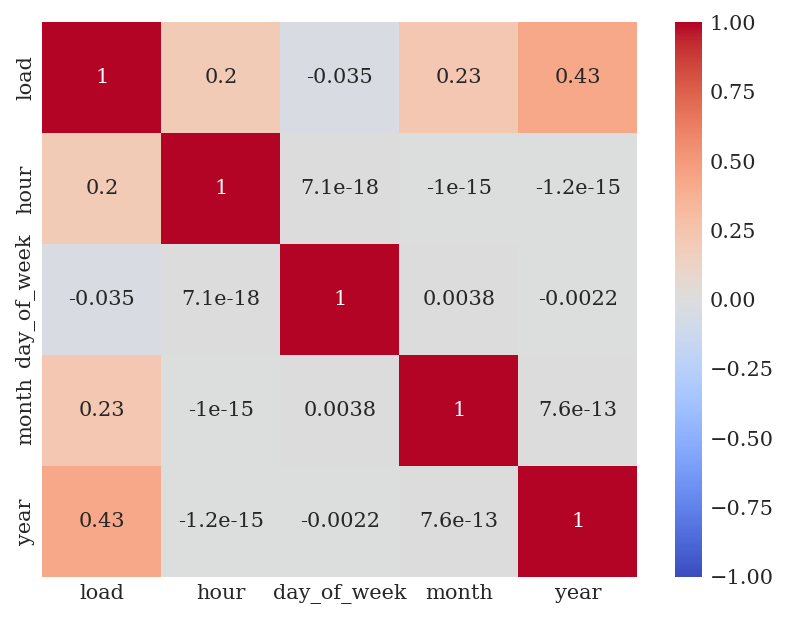

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

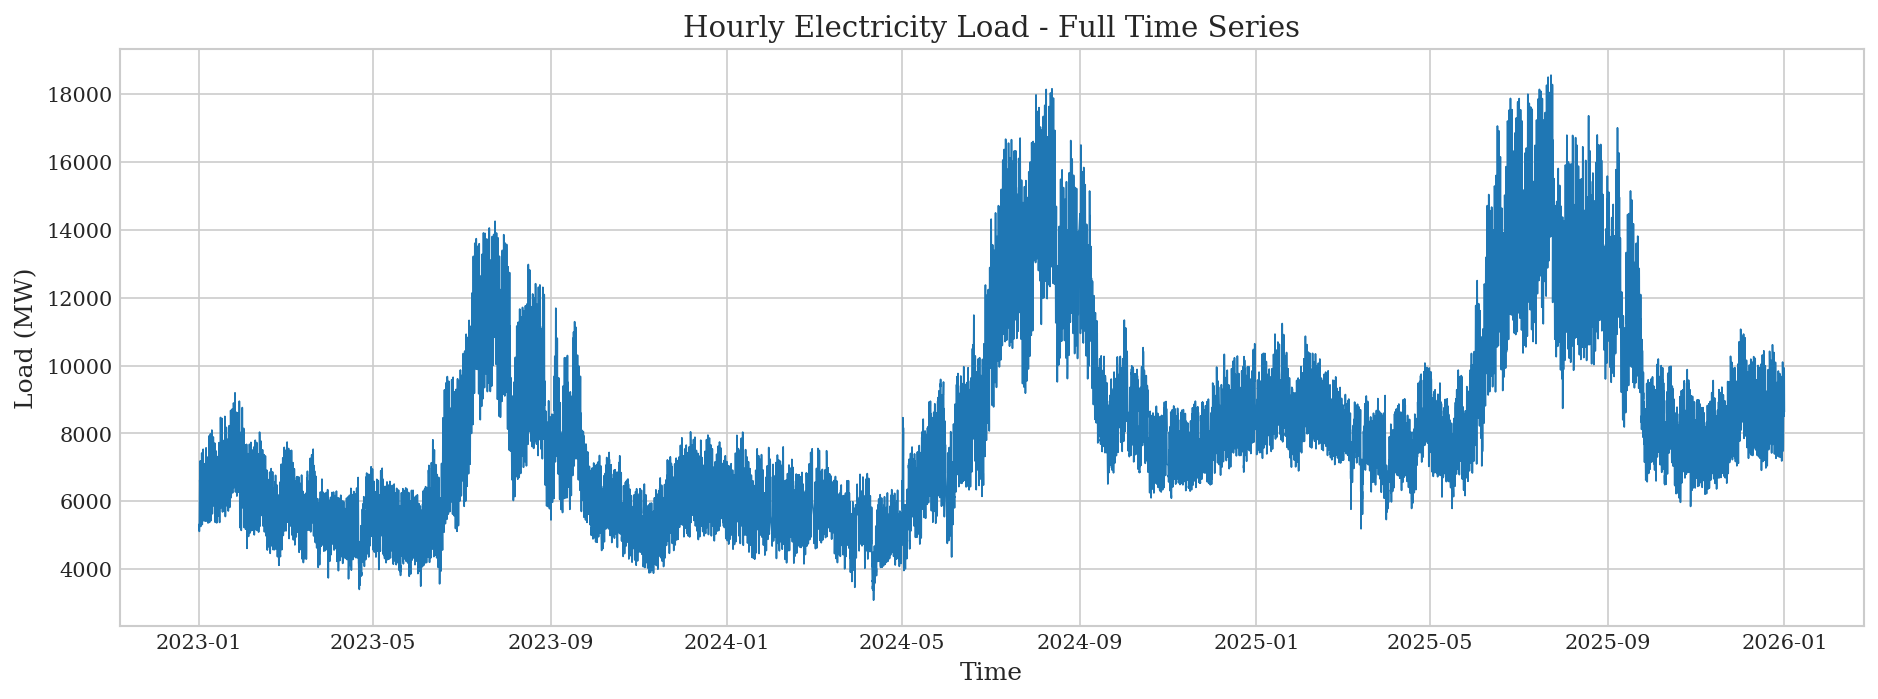

In [9]:

plt.figure(figsize=(15,5))
plt.plot(df.index, df['load'], linewidth=0.8)
plt.title("Hourly Electricity Load - Full Time Series")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

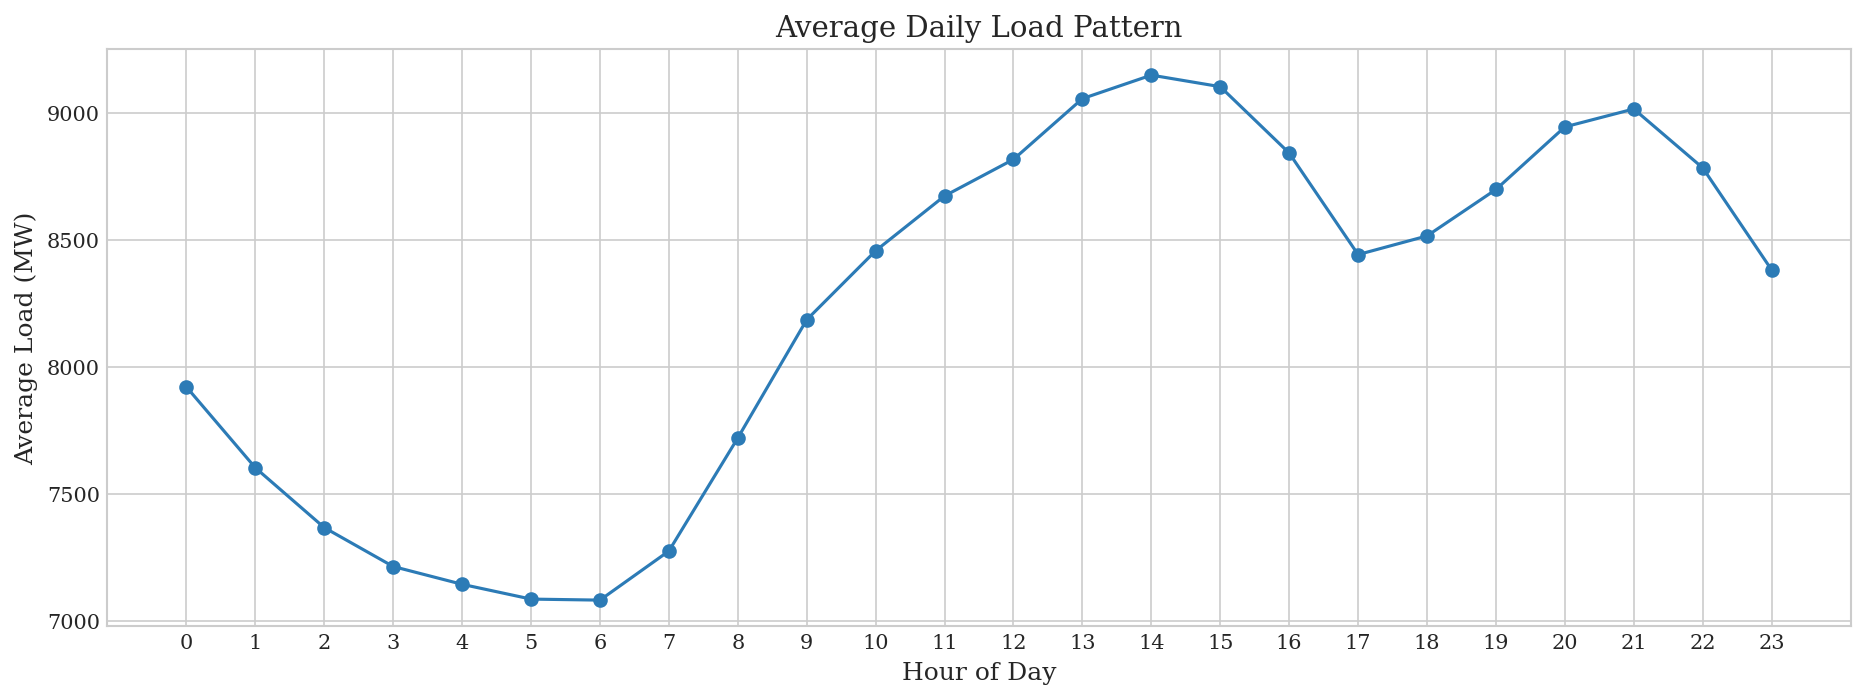

In [10]:
daily_pattern=df.groupby('hour')['load'].mean()
plt.figure(figsize=(15,5))
plt.plot(daily_pattern.index, daily_pattern.values, marker='o', color=COLORS['primary'])
plt.title("Average Daily Load Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

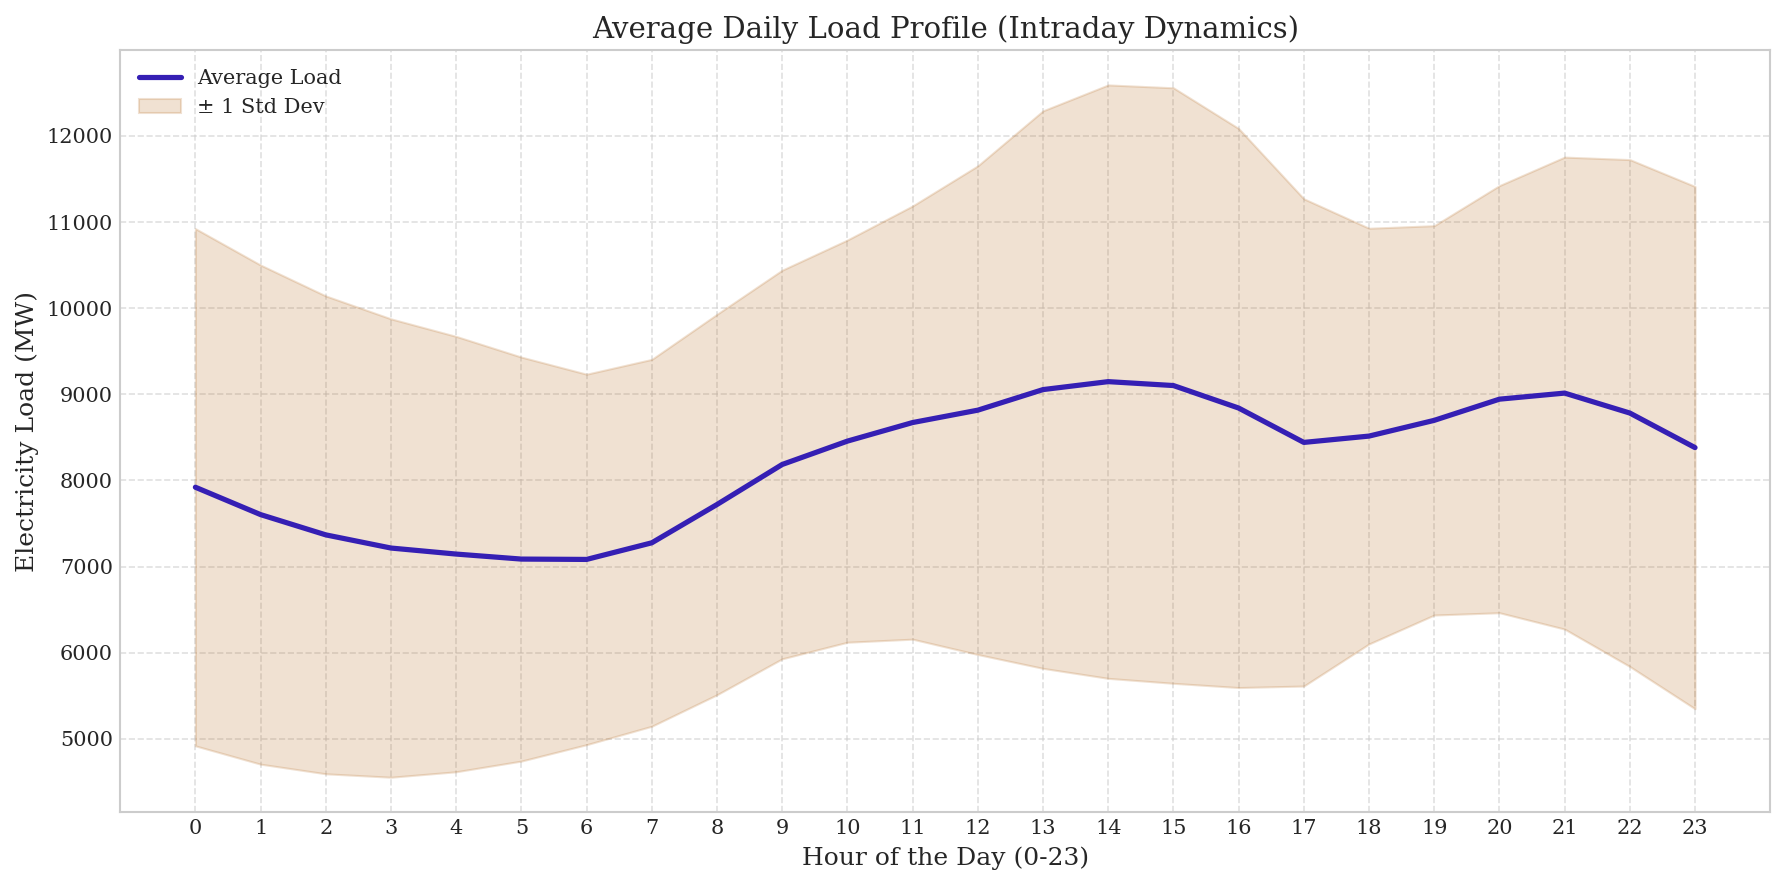

In [11]:


# Calculate the mean and standard deviation for each hour of the day (0-23)
daily_mean = df.groupby('hour')['load'].mean()
daily_std = df.groupby('hour')['load'].std()

plt.figure(figsize=(12, 6))

# Plot the average line
plt.plot(daily_mean.index, daily_mean.values, color="#351fb4", linewidth=2.5, label='Average Load')

# Add a shaded band for the standard deviation (volatility)
plt.fill_between(daily_mean.index, 
                 daily_mean.values - daily_std.values, 
                 daily_mean.values + daily_std.values, 
                 color="#b4691f", alpha=0.2, label='± 1 Std Dev')

plt.title("Average Daily Load Profile (Intraday Dynamics)")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Electricity Load (MW)")
plt.xticks(range(0, 24))
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Assuming you save your plots to an outputs folder
# plt.savefig('../outputs/daily_pattern.png', dpi=300)
plt.show()

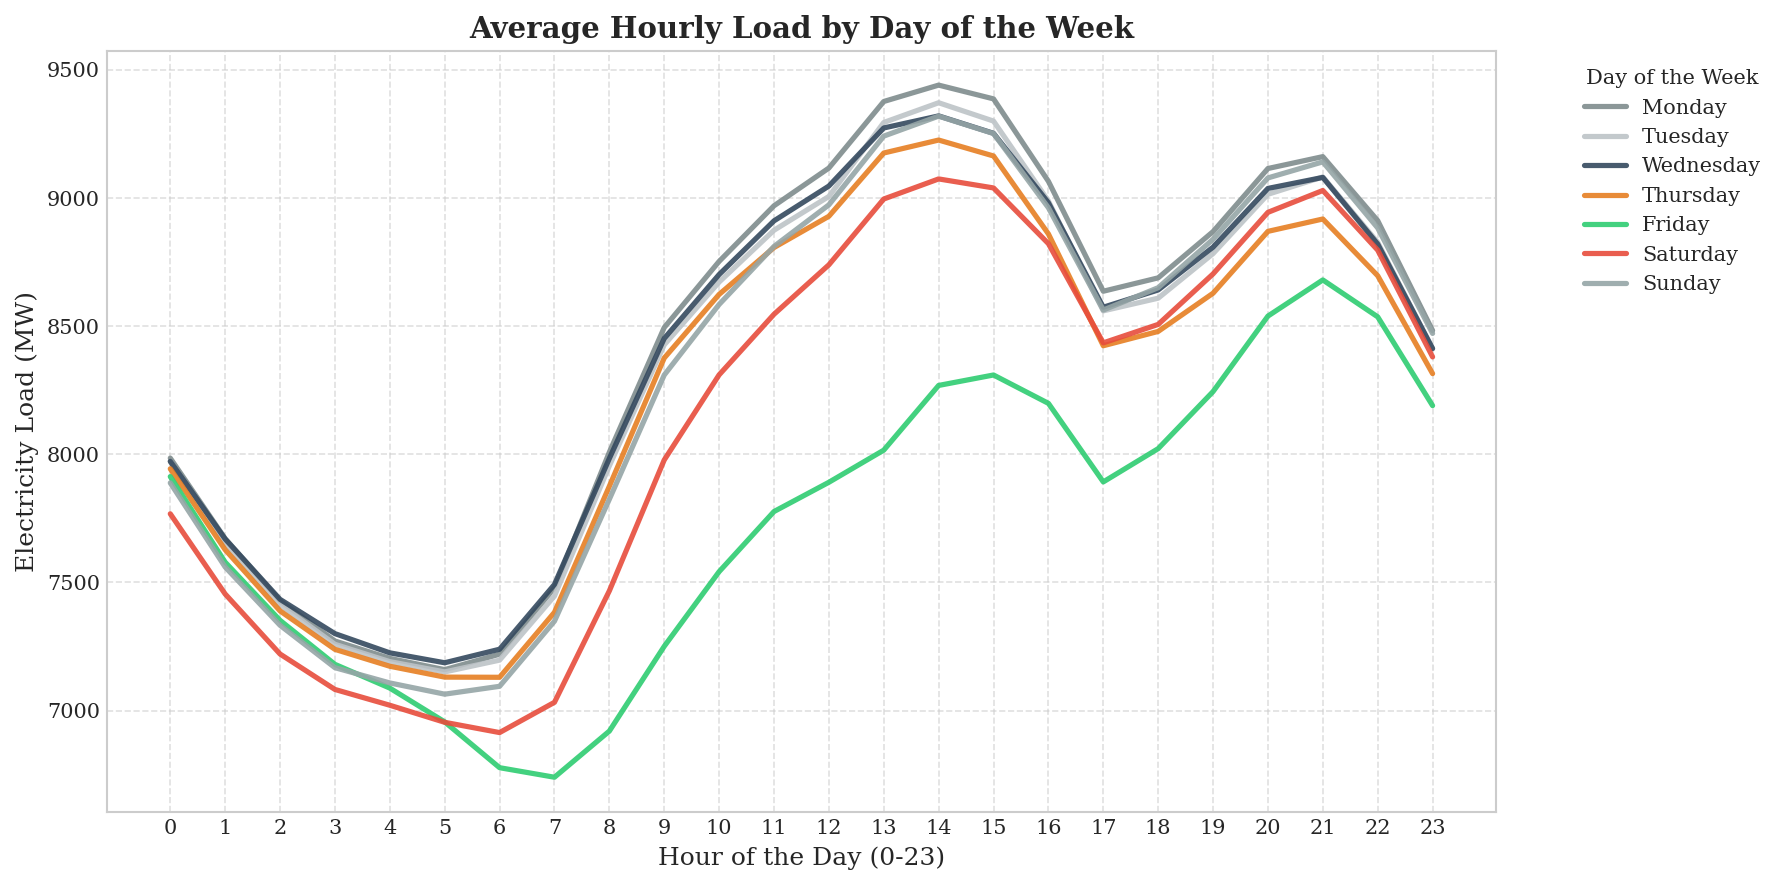

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data by day of the week and hour to find the average load
weekly_profile = df.groupby(['day_of_week', 'hour'])['load'].mean().reset_index()

# 2. Map the pandas integer days to actual names 
# (Pandas default: 0=Monday, 1=Tuesday, 2=Wednesday, 3=Thursday, 4=Friday, 5=Saturday, 6=Sunday)
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}
weekly_profile['Day'] = weekly_profile['day_of_week'].map(day_map)

# 3. Create a custom color palette to emphasize the Algerian workweek vs. weekend
palette = {
    'Sunday': '#95a5a6',    # Muted grey
    'Monday': '#7f8c8d',    # Muted grey
    'Tuesday': '#bdc3c7',   # Muted grey
    'Wednesday': '#34495e', # Darker grey/blue
    'Thursday': '#e67e22',  # Orange (Transition day)
    'Friday': '#2ecc71',    # Green (Weekend - expected lowest)
    'Saturday': '#e74c3c'   # Red (Weekend - recovery)
}

# 4. Generate the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=weekly_profile, x='hour', y='load', hue='Day', 
             palette=palette, linewidth=2.5, alpha=0.9)

plt.title("Average Hourly Load by Day of the Week", fontsize=14, weight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=12)
plt.ylabel("Electricity Load (MW)", fontsize=12)
plt.xticks(range(0, 24))

# Move the legend outside the plot so it doesn't cover the data
plt.legend(title='Day of the Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# plt.savefig('../outputs/4_5_3_weekly_pattern.png', dpi=300)
plt.show()

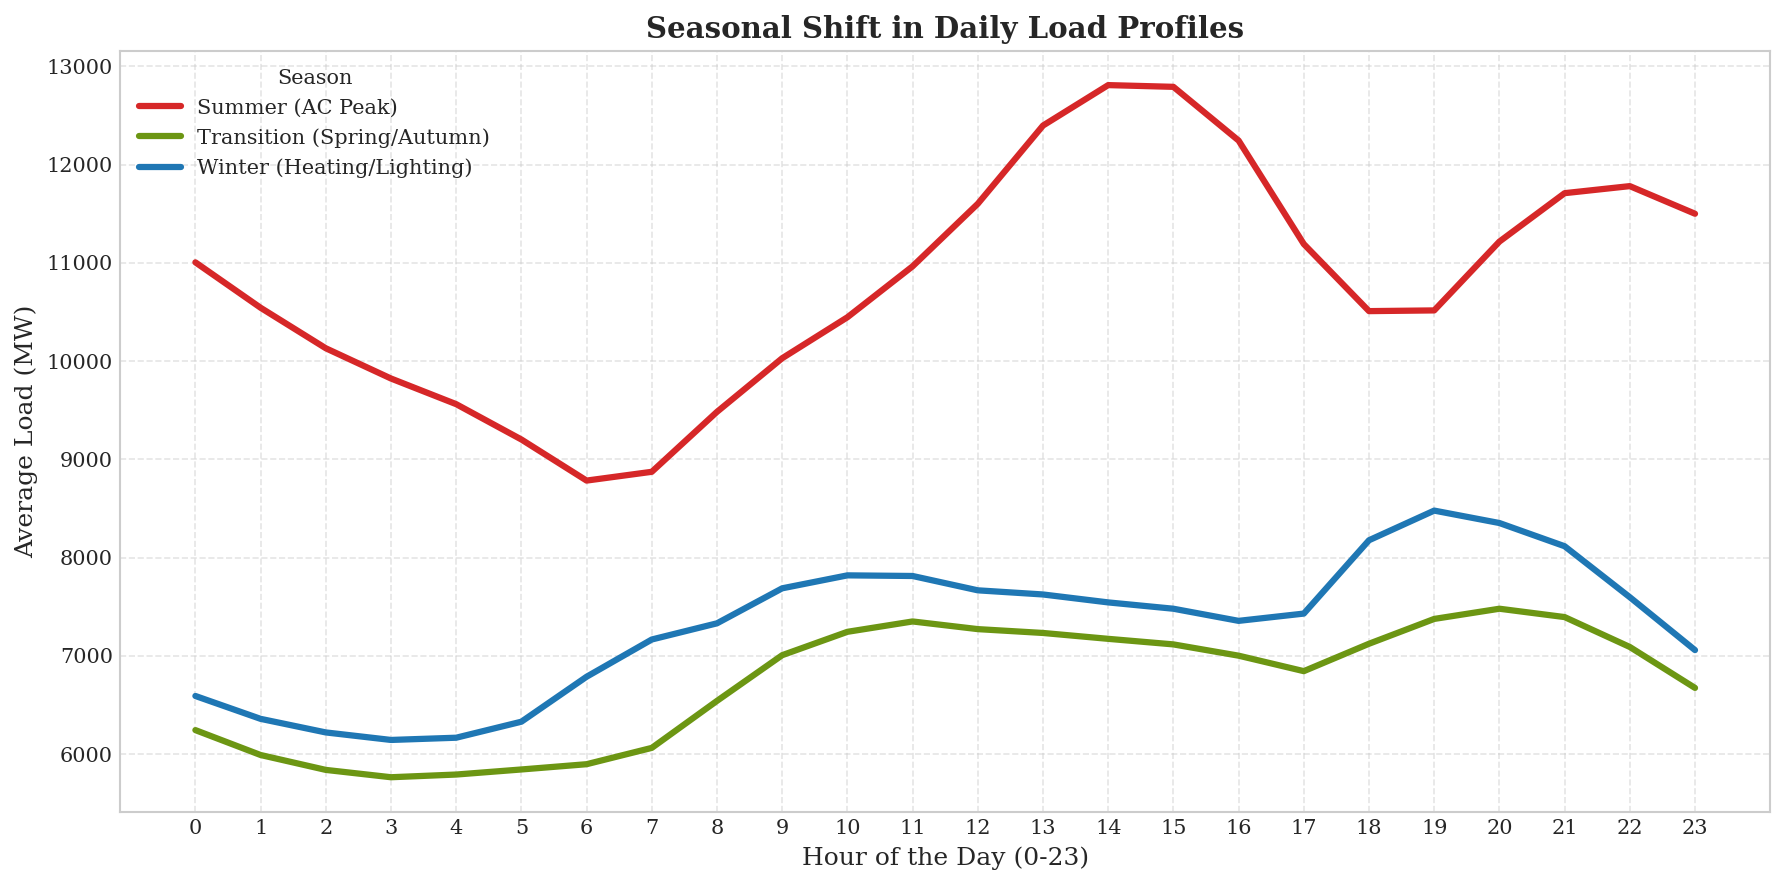

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create season labels for the plot
def get_season_name(month):
    if month in [6, 7, 8, 9]: return 'Summer (AC Peak)'
    if month in [12, 1, 2]: return 'Winter (Heating/Lighting)'
    return 'Transition (Spring/Autumn)'

df['season_label'] = df['month'].apply(get_season_name)

# 2. Calculate average hourly profile per season
seasonal_data = df.groupby(['season_label', 'hour'])['load'].mean().reset_index()

# 3. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_data, x='hour', y='load', hue='season_label', 
             palette={'Summer (AC Peak)': '#d62728', 
                      'Winter (Heating/Lighting)': '#1f77b4', 
                      'Transition (Spring/Autumn)': "#6C9613"}, linewidth=3)

plt.title("Seasonal Shift in Daily Load Profiles", fontsize=14, weight='bold')
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Average Load (MW)")
plt.xticks(range(0, 24))
plt.grid(True, ls='--', alpha=0.5)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [1]:

import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv")
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')

In [ ]:

jan_apr_2024 = df['load']['2024-01':'2024-04'].resample('M').mean()
jan_apr_2025 = df['load']['2025-01':'2025-04'].resample('M').mean()

import pandas as pd
comparison = pd.DataFrame({

    '2024': jan_apr_2024.values,
    '2025': jan_apr_2025.values
}, index=['Jan', 'Feb', 'Mar', 'Apr'])

print(comparison)
print(f"YoY growth 2024→2025: {((jan_apr_2025.mean() - jan_apr_2024.mean()) / jan_apr_2024.mean() * 100):.1f}%")

            2024         2025
Jan  5930.971539  8778.512553
Feb  5774.363147  8686.830608
Mar  5621.902554  7714.998549
Apr  5109.445660  7758.670623
YoY growth 2023-2024+ 2024-2025: 46.8%


C:\Users\Top Prix\AppData\Local\Temp\ipykernel_17860\486169903.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2024 = df['load']['2024-01':'2024-04'].resample('M').mean()
C:\Users\Top Prix\AppData\Local\Temp\ipykernel_17860\486169903.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2025 = df['load']['2025-01':'2025-04'].resample('M').mean()


In [8]:

jan_apr_2024 = df['load']['2023-07':'2024-04'].resample('M').mean()
jan_apr_2025 = df['load']['2024-07':'2025-04'].resample('M').mean()

import pandas as pd
comparison = pd.DataFrame({

    '2024': jan_apr_2024.values,
    '2025': jan_apr_2025.values
}, index=['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])

print(comparison)
print(f"YoY growth 2023→2024,2024→2025: {((jan_apr_2025.mean() - jan_apr_2024.mean()) / jan_apr_2024.mean() * 100):.1f}%")

             2024          2025
Jul  10705.802464  12986.176579
Aug   9134.887718  13744.945492
Sep   7655.834896   9989.570792
Oct   5806.782258   8223.057080
Nov   5529.792014   7634.968054
Dec   6304.764785   8559.795829
Jan   5930.971539   8778.512553
Feb   5774.363147   8686.830608
Mar   5621.902554   7714.998549
Apr   5109.445660   7758.670623
YoY growth 2023→2024,2024→2025: 39.2%


C:\Users\Top Prix\AppData\Local\Temp\ipykernel_17860\744289422.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2024 = df['load']['2023-07':'2024-04'].resample('M').mean()
C:\Users\Top Prix\AppData\Local\Temp\ipykernel_17860\744289422.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2025 = df['load']['2024-07':'2025-04'].resample('M').mean()


In [18]:
import ruptures as rpt
import numpy as np

# Use daily mean to reduce noise
daily = df['load'].resample('D').mean().values

# Pelt algorithm - detects unknown number of breakpoints
model = rpt.Pelt(model="rbf").fit(daily)
breakpoints = model.predict(pen=25)

print(breakpoints)

[165, 260, 495, 540, 610, 880, 990, 1089]


Text(0.5, 1.0, 'Change-point Detection — Daily Mean Load')

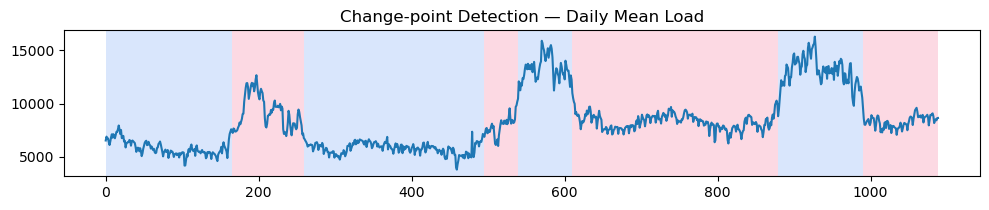

In [19]:
import matplotlib.pyplot as plt
rpt.display(daily, breakpoints)
plt.title("Change-point Detection — Daily Mean Load")

In [9]:
daily_index = df['load'].resample('D').mean().index
break_date = daily_index[breakpoints[0]-1]
print(f"Detected structural break: {break_date}")

Detected structural break: 2025-12-31 00:00:00
